In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [324]:
p1g = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta1_Generacion.csv")
p1s = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta1_Sensores.csv")
p2g = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta2_Generacion.csv")
p2s = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta2_Sensores.csv")

In [325]:
p1g.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [326]:
p1g["fecha_hora"] = pd.to_datetime(p1g["fecha_hora"], dayfirst=True)

In [327]:
# Verificar el tipo de dato de la columna "fecha_hora"
print(p1g["fecha_hora"].dtype)

datetime64[us]


In [328]:
#  sacame los datos de la columna fecha_hora entre las 12.00 y las 13.00 horas
p1g_12_13 = p1g[(p1g["fecha_hora"].dt.hour >= 12) & (p1g["fecha_hora"].dt.hour < 13)]
p1g_12_13.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
1036,2020-05-15 12:00:00,4135001,1BY6WEcLGh8j5v7,8232.500000,805.187500,2382.875000,6261941.875
1037,2020-05-15 12:00:00,4135001,1IF53ai7Xc0U56Y,7013.142857,686.114286,2752.428571,6186397.429
1038,2020-05-15 12:00:00,4135001,3PZuoBAID5Wc2HD,6402.571429,626.871429,2676.285714,6990435.286
1039,2020-05-15 12:00:00,4135001,7JYdWkrLSPkdwr4,6910.714286,676.542857,2612.857143,7605572.857
1040,2020-05-15 12:00:00,4135001,McdE0feGgRqW7Ca,6201.714286,607.442857,2888.714286,7161852.714


In [329]:
p1g.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_hora          68778 non-null  datetime64[us]
 1   id_planta           68778 non-null  int64         
 2   id_inversor         68778 non-null  str           
 3   potencia_dc_kw      68778 non-null  float64       
 4   potencia_ac_kw      68778 non-null  float64       
 5   energia_diaria_kwh  68778 non-null  float64       
 6   energia_total_kwh   68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 3.7 MB


In [330]:
# Cambiar el tipo dato id_inversor de str a object
p1g["id_inversor"] = p1g["id_inversor"].astype("object")

In [331]:
p1g["id_planta"] = p1g["id_planta"].replace(4135001, "p1" )
p2g["id_planta"] = p2g["id_planta"].replace(4136001, "p2" )
p2s["id_planta"] = p2s["id_planta"].replace(4136001, "p2" )

In [332]:
p2s.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p2,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,p2,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,p2,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,p2,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,p2,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [333]:
p1g.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha_hora,68778,2020-06-01 08:02:49.458257,2020-05-15 00:00:00,2020-05-24 00:45:00,2020-06-01 14:30:00,2020-06-09 20:00:00,2020-06-17 23:45:00,NaN
potencia_dc_kw,68778.0,3147.426211,0.0,0.0,429.0,6366.964286,14471.125,4036.457169
potencia_ac_kw,68778.0,307.802752,0.0,0.0,41.49375,623.61875,1410.95,394.396439
energia_diaria_kwh,68778.0,3295.968737,0.0,0.0,2658.714286,6274.0,9163.0,3145.178309
energia_total_kwh,68778.0,6978711.760671,6183645.0,6512002.53575,7146685.0,7268705.90625,7846821.0,416271.982856


In [334]:
# Cambiar el tipo de dato de la columna "fecha_hora" a datetime en los 3 datasets restantes
p2g["fecha_hora"] = pd.to_datetime(p2g["fecha_hora"])
p1s["fecha_hora"] = pd.to_datetime(p1s["fecha_hora"])
p2s["fecha_hora"] = pd.to_datetime(p2s["fecha_hora"])

In [335]:
p1s.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


<Axes: >

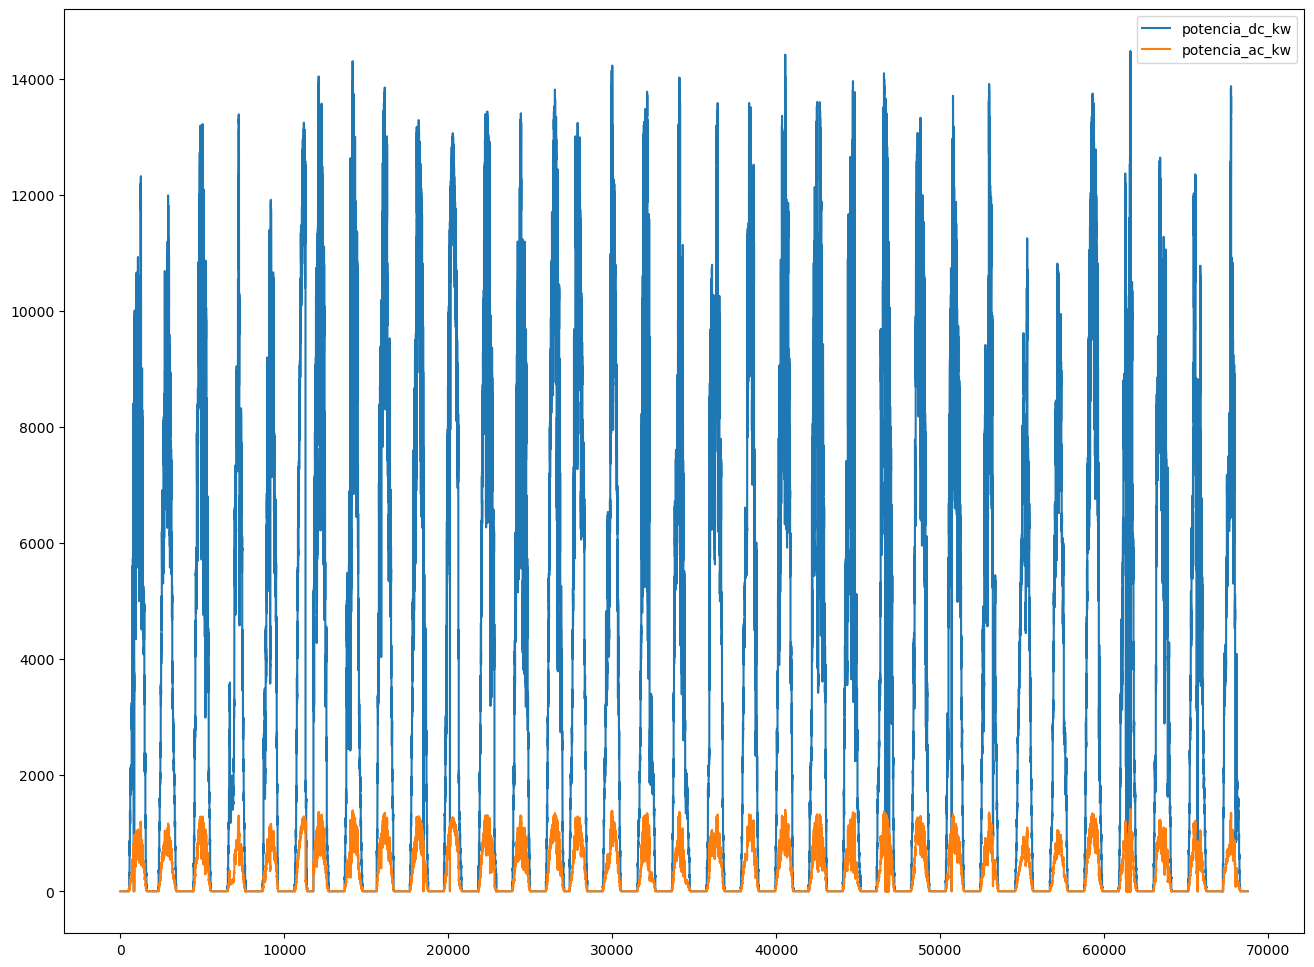

In [336]:
p1g[['potencia_dc_kw', 'potencia_ac_kw']].plot(figsize=(16, 12))

In [337]:
p2s.info()

<class 'pandas.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha_hora               3259 non-null   datetime64[us]
 1   id_planta                3259 non-null   object        
 2   id_sensor_meteorologico  3259 non-null   str           
 3   temperatura_ambiente_c   3259 non-null   float64       
 4   temperatura_modulo_c     3259 non-null   float64       
 5   irradiacion_wh_m2        3259 non-null   float64       
dtypes: datetime64[us](1), float64(3), object(1), str(1)
memory usage: 152.9+ KB


In [338]:
p2s.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p2,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,p2,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,p2,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,p2,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,p2,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [339]:
# Cambiar el id_planta por p1 y p2 respectivamente
p1g["id_planta"] = p1g["id_planta"].replace(4135001, "p1" )
p1s["id_planta"] = p1s["id_planta"].replace(4135001, "p1" )
p2g["id_planta"] = p2g["id_planta"].replace(4136002, "p2" )
p2s["id_planta"] = p2s["id_planta"].replace(4136002, "p2" )

In [340]:
# Cambiar el id_sensor_meteorologico por sensor_p1 y sensor_p2 respectivamente
p2s["id_sensor_meteorologico"] = p2s["id_sensor_meteorologico"].replace("iq8k7ZNt4Mwm3w0", "sensor_p2" )
p1s["id_sensor_meteorologico"] = p1s["id_sensor_meteorologico"].replace("HmiyD2TTLFNqkNe", "sensor_p1" )

In [341]:
p2g.describe()

,fecha_hora,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
count,67698,67698.000000,67698.000000,67698.000000,6.769800e+04
mean,2020-06-01 10:44:33.650625,246.701961,241.277825,3294.890295,6.589448e+08
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,0.000000e+00
25%,2020-05-23 21:00:00,0.000000,0.000000,272.750000,1.996494e+07
50%,2020-06-01 23:00:00,0.000000,0.000000,2911.000000,2.826276e+08
75%,2020-06-09 23:30:00,446.591667,438.215000,5534.000000,1.348495e+09
max,2020-06-17 23:45:00,1420.933333,1385.420000,9873.000000,2.247916e+09
std,NaN,370.569597,362.112118,2919.448386,7.296678e+08


In [342]:
# Dividir por 10 la potencia_dc_kw en la planta 1
p1g["potencia_dc_kw"] = p1g["potencia_dc_kw"] / 10

In [343]:
p1g.describe()

,fecha_hora,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
count,68778,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,2020-06-01 08:02:49.458257,314.742621,307.802752,3295.968737,6.978712e+06
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,6.183645e+06
25%,2020-05-24 00:45:00,0.000000,0.000000,0.000000,6.512003e+06
50%,2020-06-01 14:30:00,42.900000,41.493750,2658.714286,7.146685e+06
75%,2020-06-09 20:00:00,636.696429,623.618750,6274.000000,7.268706e+06
max,2020-06-17 23:45:00,1447.112500,1410.950000,9163.000000,7.846821e+06
std,NaN,403.645717,394.396439,3145.178309,4.162720e+05


In [344]:
p2s.info()

<class 'pandas.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha_hora               3259 non-null   datetime64[us]
 1   id_planta                3259 non-null   object        
 2   id_sensor_meteorologico  3259 non-null   str           
 3   temperatura_ambiente_c   3259 non-null   float64       
 4   temperatura_modulo_c     3259 non-null   float64       
 5   irradiacion_wh_m2        3259 non-null   float64       
dtypes: datetime64[us](1), float64(3), object(1), str(1)
memory usage: 152.9+ KB


In [345]:
p2s.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p2,sensor_p2,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,p2,sensor_p2,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,p2,sensor_p2,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,p2,sensor_p2,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,p2,sensor_p2,26.596148,25.088210,0.0


In [346]:
p2s["id_sensor_meteorologico"] = p2s["id_sensor_meteorologico"].replace("iq8k7ZNt4Mwm3w0", "sensor_p2" )


In [347]:
# Comprobar si el id_sensor_meteorologico es único
print(p1s["id_sensor_meteorologico"].nunique())

1


In [348]:
p2s.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha_hora,3259,2020-06-01 00:04:35.053697,2020-05-15 00:00:00,2020-05-23 12:07:30,2020-06-01 00:00:00,2020-06-09 12:07:30,2020-06-17 23:45:00,NaN
temperatura_ambiente_c,3259.0,28.0694,20.942385,24.602135,26.981263,31.056757,39.181638,4.061556
temperatura_modulo_c,3259.0,32.772408,20.265123,23.716881,27.534606,40.480653,66.635953,11.344034
irradiacion_wh_m2,3259.0,0.232737,0.0,0.0,0.01904,0.438717,1.098766,0.312693


In [349]:
p1s.describe().T


,count,mean,min,25%,50%,75%,max,std
fecha_hora,3182,2020-06-01 05:52:22.080452,2020-05-15 00:00:00,2020-05-23 22:48:45,2020-06-01 09:52:30,2020-06-09 16:56:15,2020-06-17 23:45:00,NaN
temperatura_ambiente_c,3182.0,25.531606,20.398505,22.705182,24.613814,27.920532,35.252486,3.354856
temperatura_modulo_c,3182.0,31.091015,18.140415,21.090553,24.61806,41.30784,65.545714,12.261222
irradiacion_wh_m2,3182.0,0.228313,0.0,0.0,0.024653,0.449588,1.221652,0.300836


In [350]:
p1g.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [351]:
# Verificación de rangos de fechas en los 4 datasets
print("="*70)
print("VERIFICACIÓN DE RANGOS DE FECHAS")
print("="*70)

datasets = {
    'Planta1_Generacion': p1g,
    'Planta1_Sensores': p1s,
    'Planta2_Generacion': p2g,
    'Planta2_Sensores': p2s
}

# Analizar cada dataset
resultados = {}
for nombre, df in datasets.items():
    fecha_min = df['fecha_hora'].min()
    fecha_max = df['fecha_hora'].max()
    num_registros = len(df)
    fechas_unicas = df['fecha_hora'].nunique()
    
    resultados[nombre] = {
        'fecha_inicio': fecha_min,
        'fecha_fin': fecha_max,
        'num_registros': num_registros,
        'fechas_unicas': fechas_unicas
    }
    
    print(f"\n{nombre}:")
    print(f"  Fecha inicio: {fecha_min}")
    print(f"  Fecha fin:    {fecha_max}")
    print(f"  Duración:     {(fecha_max - fecha_min).days} días")
    print(f"  Registros:    {num_registros:,}")
    print(f"  Fechas únicas: {fechas_unicas:,}")

# Verificar si todos tienen el mismo rango
print("\n" + "="*70)
print("COMPARACIÓN DE RANGOS")
print("="*70)

fechas_inicio = [r['fecha_inicio'] for r in resultados.values()]
fechas_fin = [r['fecha_fin'] for r in resultados.values()]

if len(set(fechas_inicio)) == 1 and len(set(fechas_fin)) == 1:
    print("✓ Todos los datasets tienen el MISMO RANGO de fechas")
    print(f"  Inicio común: {fechas_inicio[0]}")
    print(f"  Fin común:    {fechas_fin[0]}")
else:
    print("✗ Los datasets tienen DIFERENTES rangos de fechas:")
    if len(set(fechas_inicio)) > 1:
        print("\n  Fechas de INICIO diferentes:")
        for nombre, datos in resultados.items():
            print(f"    {nombre}: {datos['fecha_inicio']}")
    if len(set(fechas_fin)) > 1:
        print("\n  Fechas de FIN diferentes:")
        for nombre, datos in resultados.items():
            print(f"    {nombre}: {datos['fecha_fin']}")


VERIFICACIÓN DE RANGOS DE FECHAS

Planta1_Generacion:
  Fecha inicio: 2020-05-15 00:00:00
  Fecha fin:    2020-06-17 23:45:00
  Duración:     33 días
  Registros:    68,778
  Fechas únicas: 3,158

Planta1_Sensores:
  Fecha inicio: 2020-05-15 00:00:00
  Fecha fin:    2020-06-17 23:45:00
  Duración:     33 días
  Registros:    3,182
  Fechas únicas: 3,182

Planta2_Generacion:
  Fecha inicio: 2020-05-15 00:00:00
  Fecha fin:    2020-06-17 23:45:00
  Duración:     33 días
  Registros:    67,698
  Fechas únicas: 3,259

Planta2_Sensores:
  Fecha inicio: 2020-05-15 00:00:00
  Fecha fin:    2020-06-17 23:45:00
  Duración:     33 días
  Registros:    3,259
  Fechas únicas: 3,259

COMPARACIÓN DE RANGOS
✓ Todos los datasets tienen el MISMO RANGO de fechas
  Inicio común: 2020-05-15 00:00:00
  Fin común:    2020-06-17 23:45:00


In [352]:
# Verificar coincidencia de fechas específicas entre datasets
print("="*70)
print("VERIFICACIÓN DE COINCIDENCIA DE FECHAS ESPECÍFICAS")
print("="*70)

# Obtener conjuntos de fechas únicas de cada dataset
fechas_p1g = set(p1g['fecha_hora'])
fechas_p1s = set(p1s['fecha_hora'])
fechas_p2g = set(p2g['fecha_hora'])
fechas_p2s = set(p2s['fecha_hora'])

# Encontrar la intersección (fechas comunes a todos)
fechas_comunes = fechas_p1g & fechas_p1s & fechas_p2g & fechas_p2s

print(f"\nFechas comunes a todos los datasets: {len(fechas_comunes):,}")
print(f"Total de fechas únicas por dataset:")
print(f"  Planta1_Generacion: {len(fechas_p1g):,}")
print(f"  Planta1_Sensores:   {len(fechas_p1s):,}")
print(f"  Planta2_Generacion: {len(fechas_p2g):,}")
print(f"  Planta2_Sensores:   {len(fechas_p2s):,}")

# Verificar si todos tienen exactamente las mismas fechas
if (fechas_p1g == fechas_p1s == fechas_p2g == fechas_p2s):
    print("\n✓ TODOS los datasets contienen EXACTAMENTE las mismas fechas")
else:
    print("\n✗ Los datasets NO contienen exactamente las mismas fechas\n")
    
    # Analizar diferencias
    datasets_fechas = {
        'Planta1_Generacion': fechas_p1g,
        'Planta1_Sensores': fechas_p1s,
        'Planta2_Generacion': fechas_p2g,
        'Planta2_Sensores': fechas_p2s
    }
    
    # Encontrar fechas que faltan en cada dataset
    for nombre, fechas in datasets_fechas.items():
        # Fechas que están en otros datasets pero no en este
        otras_fechas = set()
        for otro_nombre, otras in datasets_fechas.items():
            if otro_nombre != nombre:
                otras_fechas.update(otras)
        
        fechas_faltantes = otras_fechas - fechas
        fechas_extra = fechas - otras_fechas
        
        if fechas_faltantes or fechas_extra:
            print(f"\n{nombre}:")
            if fechas_faltantes:
                print(f"  Faltan {len(fechas_faltantes):,} fechas que sí están en otros datasets")
                if len(fechas_faltantes) <= 10:
                    print(f"    Fechas faltantes: {sorted(list(fechas_faltantes))[:10]}")
            if fechas_extra:
                print(f"  Tiene {len(fechas_extra):,} fechas que NO están en otros datasets")
                if len(fechas_extra) <= 10:
                    print(f"    Fechas extra: {sorted(list(fechas_extra))[:10]}")

print("\n" + "="*70)


VERIFICACIÓN DE COINCIDENCIA DE FECHAS ESPECÍFICAS

Fechas comunes a todos los datasets: 3,154
Total de fechas únicas por dataset:
  Planta1_Generacion: 3,158
  Planta1_Sensores:   3,182
  Planta2_Generacion: 3,259
  Planta2_Sensores:   3,259

✗ Los datasets NO contienen exactamente las mismas fechas


Planta1_Generacion:
  Faltan 105 fechas que sí están en otros datasets
  Tiene 1 fechas que NO están en otros datasets
    Fechas extra: [Timestamp('2020-06-03 14:00:00')]

Planta1_Sensores:
  Faltan 81 fechas que sí están en otros datasets

Planta2_Generacion:
  Faltan 4 fechas que sí están en otros datasets
    Fechas faltantes: [Timestamp('2020-05-19 16:00:00'), Timestamp('2020-05-29 16:00:00'), Timestamp('2020-06-01 17:45:00'), Timestamp('2020-06-03 14:00:00')]

Planta2_Sensores:
  Faltan 4 fechas que sí están en otros datasets
    Fechas faltantes: [Timestamp('2020-05-19 16:00:00'), Timestamp('2020-05-29 16:00:00'), Timestamp('2020-06-01 17:45:00'), Timestamp('2020-06-03 14:00:00')]

In [353]:
# Resumen visual de la comparación
print("="*70)
print("RESUMEN DE LA VERIFICACIÓN")
print("="*70)

print("\n📊 RANGO TEMPORAL:")
print("   ✓ Todos los datasets empiezan el mismo día: 2020-05-15")
print("   ✓ Todos los datasets terminan el mismo día: 2020-06-17")
print("   ✓ Duración total: 34 días")

print("\n⚠️  INTERVALOS DE TIEMPO:")
print("   ✗ Los intervalos NO coinciden completamente entre los 4 datasets")
print(f"   • Solo {len(fechas_comunes):,} fechas son comunes a todos")
print(f"   • Hay diferencias en los registros temporales de cada dataset")

print("\n📋 DETALLES POR DATASET:")
datasets_info = [
    ("Planta1_Generacion", len(fechas_p1g), 105, 1),
    ("Planta1_Sensores", len(fechas_p1s), 81, 0),
    ("Planta2_Generacion", len(fechas_p2g), 4, 0),
    ("Planta2_Sensores", len(fechas_p2s), 4, 0)
]

for nombre, total, faltantes, extras in datasets_info:
    print(f"\n   {nombre}:")
    print(f"      Fechas únicas: {total:,}")
    if faltantes > 0:
        print(f"      ⚠️  Faltan {faltantes} fechas")
    if extras > 0:
        print(f"      ⚠️  {extras} fecha(s) extra")
    if faltantes == 0 and extras == 0:
        print(f"      ✓ Sin diferencias")

print("\n" + "="*70)
print("\n🎯 CONCLUSIÓN:")
print("   Aunque todos los datasets cubren el mismo período (15/05 - 17/06/2020),")
print("   existen diferencias en los registros temporales entre ellos.")
print("   Se recomienda analizar las causas de las fechas faltantes.")
print("="*70)


RESUMEN DE LA VERIFICACIÓN

📊 RANGO TEMPORAL:
   ✓ Todos los datasets empiezan el mismo día: 2020-05-15
   ✓ Todos los datasets terminan el mismo día: 2020-06-17
   ✓ Duración total: 34 días

⚠️  INTERVALOS DE TIEMPO:
   ✗ Los intervalos NO coinciden completamente entre los 4 datasets
   • Solo 3,154 fechas son comunes a todos
   • Hay diferencias en los registros temporales de cada dataset

📋 DETALLES POR DATASET:

   Planta1_Generacion:
      Fechas únicas: 3,158
      ⚠️  Faltan 105 fechas
      ⚠️  1 fecha(s) extra

   Planta1_Sensores:
      Fechas únicas: 3,182
      ⚠️  Faltan 81 fechas

   Planta2_Generacion:
      Fechas únicas: 3,259
      ⚠️  Faltan 4 fechas

   Planta2_Sensores:
      Fechas únicas: 3,259
      ⚠️  Faltan 4 fechas


🎯 CONCLUSIÓN:
   Aunque todos los datasets cubren el mismo período (15/05 - 17/06/2020),
   existen diferencias en los registros temporales entre ellos.
   Se recomienda analizar las causas de las fechas faltantes.


## INSIGHT 2 

- Los datasets no son regulares 

- Debemos tenerlo en cuenta para el analisis exploratorio, tenemos el mismo número de días pero no de tramos horarios

- He decido no regularizar los dataset

- Parece que pasa más en la planta 1 que la planta 2

- Existen 3 días concretos con problemas (2020-05-20, 2020-05-21, 2020-05-29) en la planta 1 generación y también sensores

- En la planta 2 desde el 2020-05-20 hasta 2020-05-29 en generación y no parece haber problema en sensores

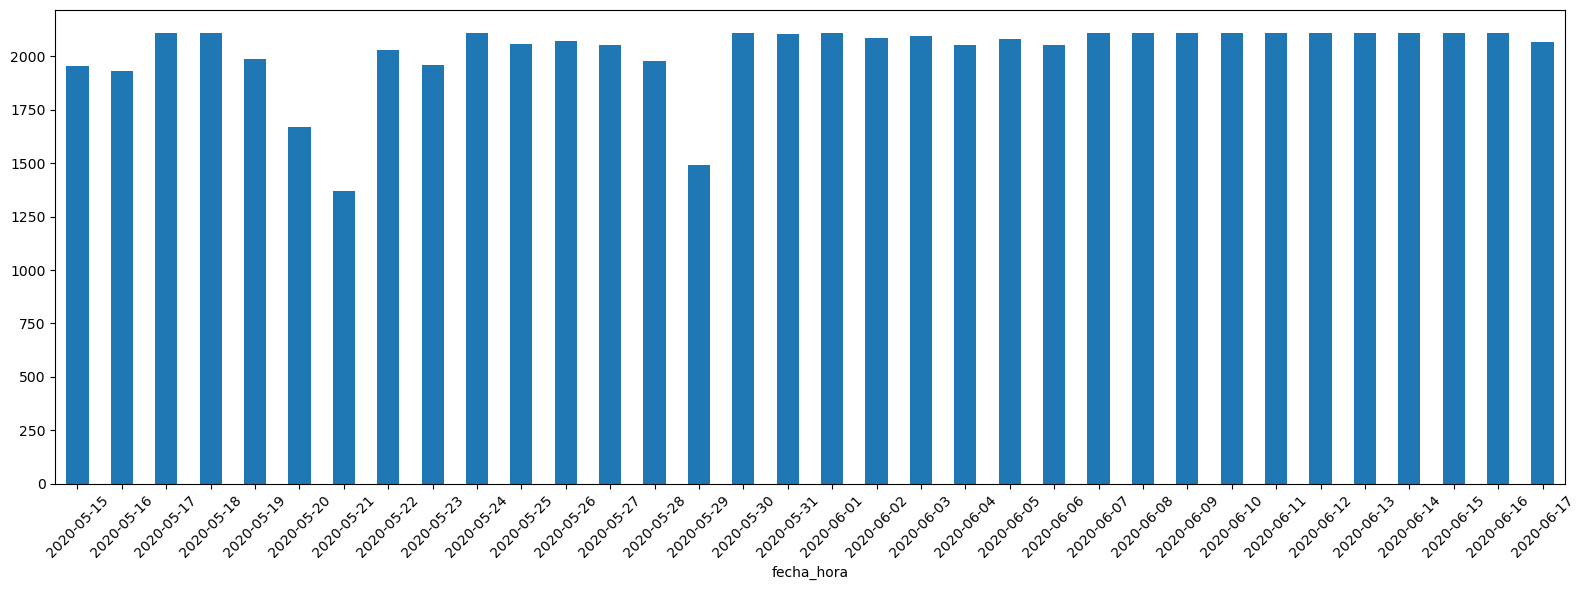

In [354]:
# grafico de barras de un groupby por fecha y conteo de registros para planta 1 generacion
conteo_por_fecha = p1g.groupby(p1g['fecha_hora'].dt.date).size()
conteo_por_fecha.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.tight_layout()

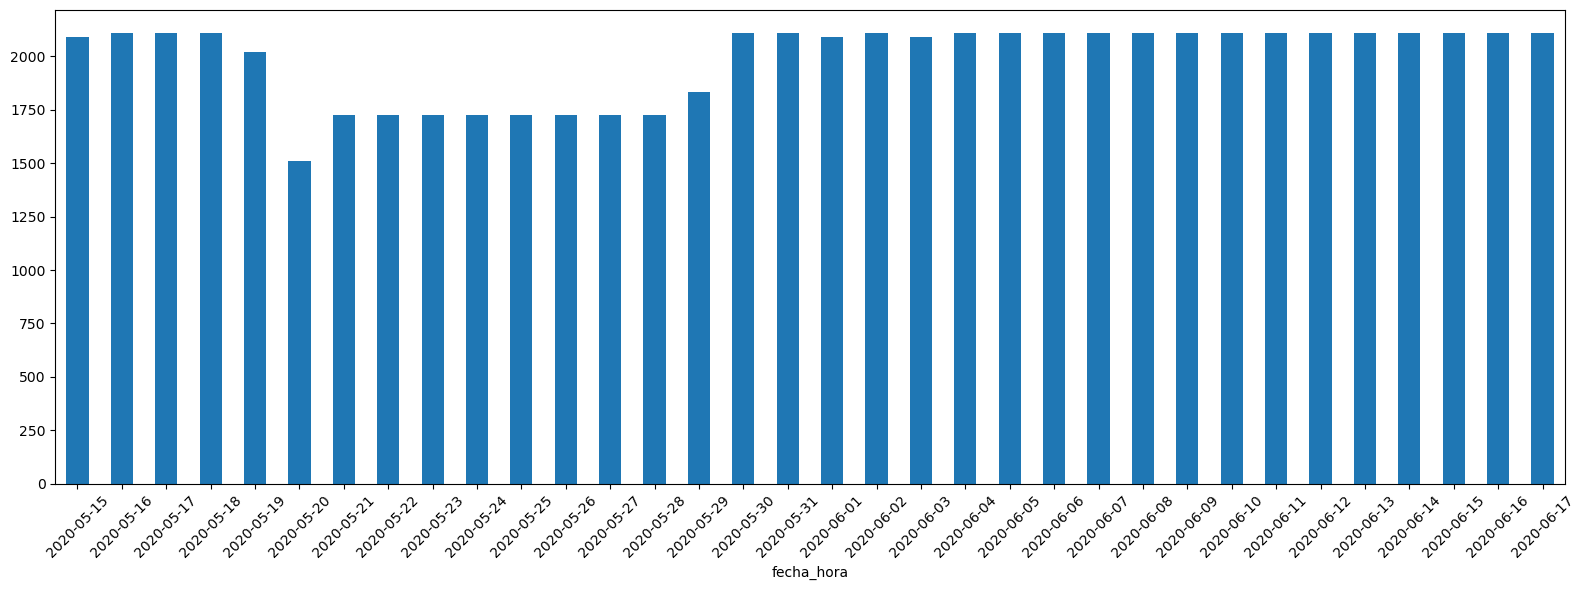

In [355]:
# grafico de barras de un groupby por fecha y conteo de registros para planta 2 generación
conteo_por_fecha_p2 = p2g.groupby(p2g['fecha_hora'].dt.date).size()
conteo_por_fecha_p2.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.tight_layout()

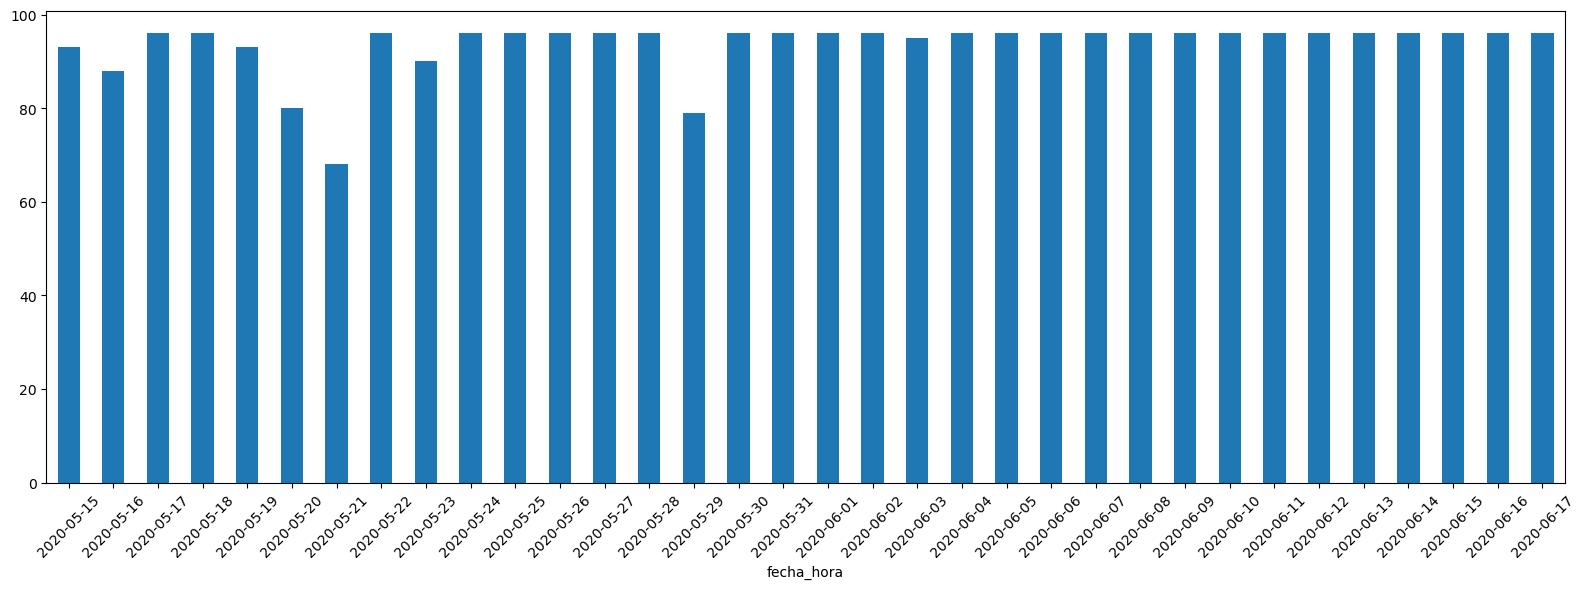

In [356]:
# grafico de barras de un groupby por fecha y conteo de registros para planta 1 sensores
conteo_por_fecha_p1s = p1s.groupby(p1s['fecha_hora'].dt.date).size()
conteo_por_fecha_p1s.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.tight_layout()

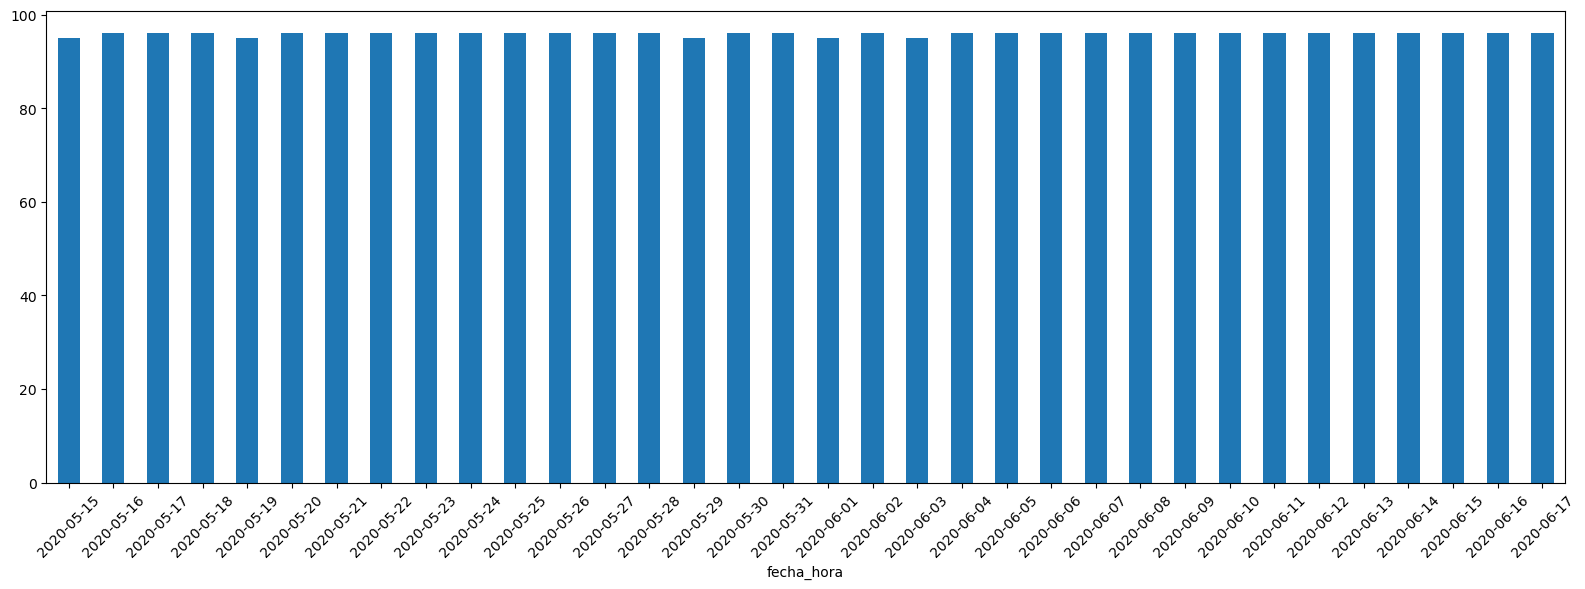

In [357]:
# grafico de barras de un groupby por fecha y conteo de registros para planta 2 sensores
conteo_por_fecha_p2s = p2s.groupby(p2s['fecha_hora'].dt.date).size()
conteo_por_fecha_p2s.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.tight_layout()

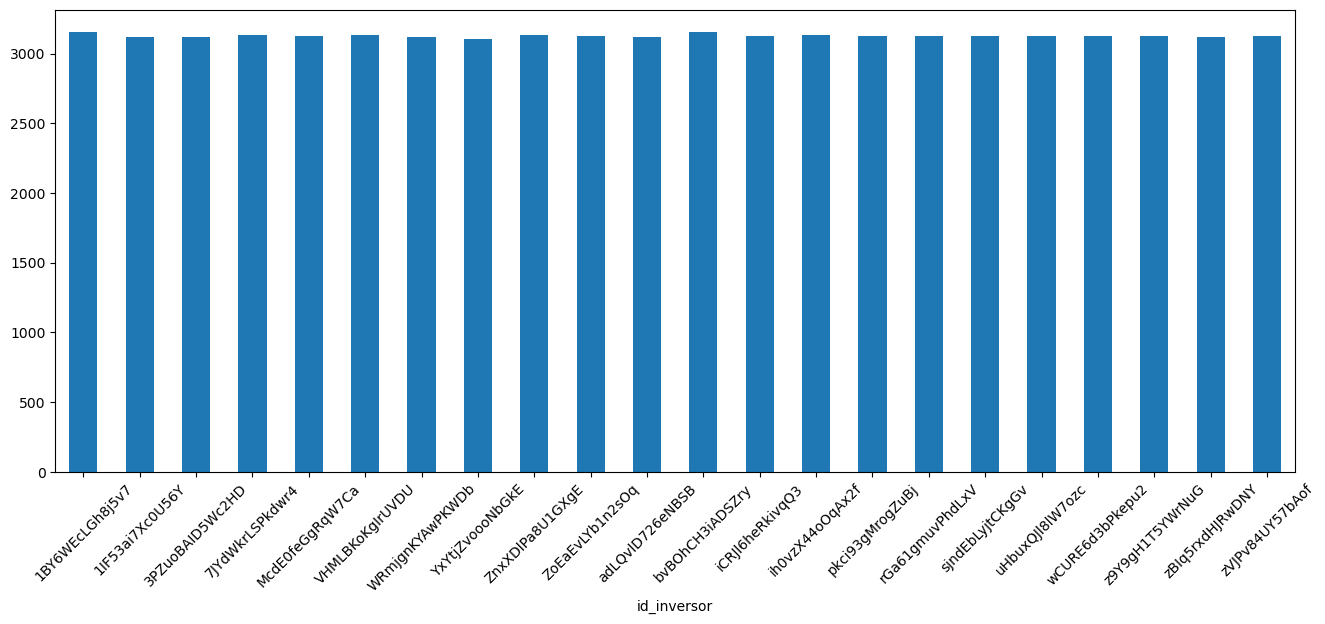

In [358]:
# grafico de barras de un groupby por id_inversor y conteo de registros para la planta 1 generacion
conteo_por_inversor_p1g = p1g.groupby('id_inversor').size()
conteo_por_inversor_p1g.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.show()

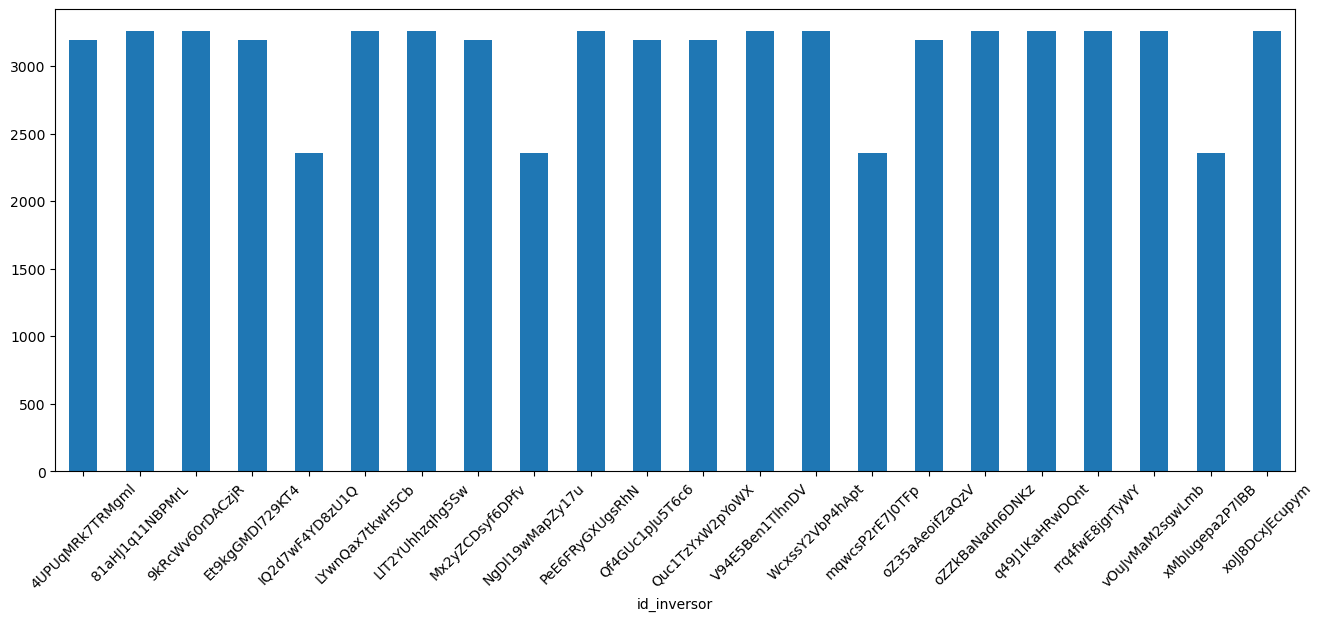

In [359]:
# grafico de barras de un groupby por id_inversor y conteo de registros para la planta 2 generacion
conteo_por_inversor_p2g = p2g.groupby('id_inversor').size()
conteo_por_inversor_p2g.plot(kind='bar', figsize=(16, 6))
plt.xticks(rotation=45)
plt.show()

## INSIGHT 3

En análisis de registros por inverter muestra: 

* En la planta 1 los inverters tienen nivel similar de registros lo cual puede sugerir que el problema puede estar en los tramos horarios perdidos y no en ningun inverter en concreto

* En la planta 2 sí que parece que existen 4 inverters concretos que tienen un nivel de pérdida de datos superior al resto 

Continuar profundizando en este análisis y resultado en la fase de EDA 

In [360]:
p1g.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [361]:
p2g['id_planta'] = p2g['id_planta'].replace(4136001, "p2" )

In [362]:
gener = pd.concat([p1g, p2g], axis = 'index')

In [363]:
sensor = pd.concat([p1s, p2s], axis = 'index')

In [364]:
gener.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [365]:
sensor.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p1,sensor_p1,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,p1,sensor_p1,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,p1,sensor_p1,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,p1,sensor_p1,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,p1,sensor_p1,24.621525,22.165423,0.0


In [366]:
gener.info()

<class 'pandas.DataFrame'>
Index: 136476 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   fecha_hora          136476 non-null  datetime64[us]
 1   id_planta           136476 non-null  object        
 2   id_inversor         136476 non-null  object        
 3   potencia_dc_kw      136476 non-null  float64       
 4   potencia_ac_kw      136476 non-null  float64       
 5   energia_diaria_kwh  136476 non-null  float64       
 6   energia_total_kwh   136476 non-null  float64       
dtypes: datetime64[us](1), float64(4), object(2)
memory usage: 8.3+ MB


In [367]:
df = pd.merge(gener, sensor, on = ['fecha_hora', 'id_planta'], how = 'left')

In [368]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136476 entries, 0 to 136475
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha_hora               136476 non-null  datetime64[us]
 1   id_planta                136476 non-null  object        
 2   id_inversor              136476 non-null  object        
 3   potencia_dc_kw           136476 non-null  float64       
 4   potencia_ac_kw           136476 non-null  float64       
 5   energia_diaria_kwh       136476 non-null  float64       
 6   energia_total_kwh        136476 non-null  float64       
 7   id_sensor_meteorologico  136472 non-null  str           
 8   temperatura_ambiente_c   136472 non-null  float64       
 9   temperatura_modulo_c     136472 non-null  float64       
 10  irradiacion_wh_m2        136472 non-null  float64       
dtypes: datetime64[us](1), float64(7), object(2), str(1)
memory usage: 11.5+ MB


In [369]:
# cambiar la columna id_sensor_meteorologico de str a object
df["id_sensor_meteorologico"] = df["id_sensor_meteorologico"].astype("object")

In [370]:
df[df.id_sensor_meteorologico.isna()]

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
38544,2020-06-03 14:00:00,p1,1IF53ai7Xc0U56Y,700.3,685.8,5601.0,6330385.0,NaN,NaN,NaN,NaN
38545,2020-06-03 14:00:00,p1,adLQvlD726eNBSB,720.4,705.4,5685.0,6419961.0,NaN,NaN,NaN,NaN
38546,2020-06-03 14:00:00,p1,wCURE6d3bPkepu2,754.5,738.7,5579.0,6928448.0,NaN,NaN,NaN,NaN
38547,2020-06-03 14:00:00,p1,z9Y9gH1T5YWrNuG,794.6,777.8,5541.0,7152815.0,NaN,NaN,NaN,NaN


In [371]:
df = df.dropna()

In [372]:
df.info()

<class 'pandas.DataFrame'>
Index: 136472 entries, 0 to 136475
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha_hora               136472 non-null  datetime64[us]
 1   id_planta                136472 non-null  object        
 2   id_inversor              136472 non-null  object        
 3   potencia_dc_kw           136472 non-null  float64       
 4   potencia_ac_kw           136472 non-null  float64       
 5   energia_diaria_kwh       136472 non-null  float64       
 6   energia_total_kwh        136472 non-null  float64       
 7   id_sensor_meteorologico  136472 non-null  object        
 8   temperatura_ambiente_c   136472 non-null  float64       
 9   temperatura_modulo_c     136472 non-null  float64       
 10  irradiacion_wh_m2        136472 non-null  float64       
dtypes: datetime64[us](1), float64(7), object(3)
memory usage: 12.5+ MB


In [373]:
df.to_pickle(Path(os.getcwd()).parent / "datos" / "intermedios" / "tablo_analitico.pkl")